# Using a Virtual Datacube for TEMPO data

## Overview

Use a Icechunk reference file for cloud-based TEMPO satellite data analysis without downloading files.

**What You'll Work With:**

- A 6MB Kerchunk file representing around 30GB of satellite data
- A virtual datacube that points directly to data in the NASA Earthdata Cloud
- Creating a visualization from cloud data without full downloads

## Prerequisites
- NASA Earthdata account ([sign up here](https://urs.earthdata.nasa.gov/users/new))

## Virtual vs Traditional Approach

* **Traditional:** Download files (GB-TB) → Load into memory (or run out of memory) → Analyze 
* **Virtual:** Use lightweight reference files (MB) → Access on-demand (without downloading) → Analyze at scale

---

## 1. Setup

Configure cloud access and initialize essential libraries, including:

- **icechunk**: Virtual data store handling
- **xarray**: Multidimensional data handling
- **cartopy** and **matplotlib** for plotting

In [1]:
import warnings
from datetime import datetime
from urllib.parse import urlparse

import earthaccess
import xarray as xr
import icechunk as ic
from icechunk import IcechunkStore, S3StaticCredentials, s3_storage

In [2]:
# earthaccess is used to authenticate
earthaccess.login()

## Helper Functions

In [3]:
class S3IcechunkCredentials:
    def __init__(self, endpoint: str):
        self.endpoint = endpoint

    def __call__(self) -> S3StaticCredentials:
        if not earthaccess.__auth__.authenticated:
            raise ValueError(
                "A valid Earthdata login instance is required to retrieve credentials for icechunk stores"
            )
        creds = earthaccess.__auth__.get_s3_credentials(endpoint=self.endpoint)
        if len(creds) == 0:
            raise ValueError(f"Got no credentials from endpoint {self.endpoint}")
        return S3StaticCredentials(
            access_key_id=creds["accessKeyId"],
            secret_access_key=creds["secretAccessKey"],
            expires_after=datetime.fromisoformat(creds["expiration"]),
            session_token=creds["sessionToken"],
        )

In [4]:
def get_virtual_chunk_credentials(
    storage: ic.Storage,
) -> dict[str, ic.AnyCredential | None]:
    """Function to retrieve virtual chunk containers from icechunk storage and authenticate
    all allowed virtual chunk prefixes using EDL credentials.
    """
    # get config and extract virtual containers
    config = ic.Repository.fetch_config(storage=storage)
    # TODO: accommodate case without virtual chunk containers.
    if not config:
        msg = f"Got empty config from {storage=} and will not try to infer chunk containers. If this is a native store this behavior is expected if the config was not persisted to storage."
        warnings.warn(message=msg)
        vchunk_container_urls: List[str] = []
    else:
        vchunk_containers = config.virtual_chunk_containers
        if vchunk_containers:
            vchunk_container_urls = list(vchunk_containers.keys())
        else:
            raise ValueError("No virtual chunk containers found.")

    # try to build authentication for all virtual chunk containers. If any of the virtual
    # chunk containers is not 'approved' it will raise an error in `_get_credential_endpoint`.
    # We will catch the error here, warn, and only return the authenticated urls.
    # Users will then get an error for the remaining containers and need to add those manually!
    failed_container_urls = []
    credential_mapping = {}
    for url in vchunk_container_urls:
        try:
            # endpoint = _get_credential_endpoint(url)
            endpoint = "https://data.asdc.earthdata.nasa.gov/s3credentials"
            credential_mapping[url] = ic.s3_refreshable_credentials(
                S3IcechunkCredentials(endpoint=endpoint)
            )
        except ValueError:
            failed_container_urls.append(url)

    if len(failed_container_urls) > 0:
        # TODO: link to credentials in icechunk + docs about the endpoint registry
        warnings.warn(
            f"Could not build virtual chunk credentials for {failed_container_urls}.\
                      If the URL is a non EDL bucket, you have to manually construct credentials (...)"
        )

    # TODO: Check how easy it is to 'splice' this output with manually created credentials
    return ic.containers_credentials(credential_mapping)

## 2. Configuration

In [5]:
CREDENTIALS_URL = "https://data.asdc.earthdata.nasa.gov/s3credentials"
REF_BUCKET = "asdc-prod-public"
REFERENCES_S3_URL_PREFIX = "virtual-reference-docs/TEMPO_L3_V04_icechunk_for_202601/"

In [6]:
repo_storage = ic.s3_storage(
    bucket=REF_BUCKET, 
    prefix=REFERENCES_S3_URL_PREFIX, 
    get_credentials=S3IcechunkCredentials(endpoint=CREDENTIALS_URL)
)
print(f"✓ Using S3 storage: {repo_storage}")

✓ Using S3 storage: S3Storage(bucket=asdc-prod-public, prefix=virtual-reference-docs/TEMPO_L3_V04_icechunk_for_202601/, config=S3Options(region=None, endpoint_url=None, anonymous=false, allow_http=false, force_path_style=false, network_stream_timeout_seconds=60, requester_pays=false))


## 3. Load Virtual Datacube

In [7]:
warnings.filterwarnings(
    "ignore",
    message="Numcodecs codecs are not in the Zarr version 3 specification*",
    category=UserWarning
)

In [8]:
# Open authenticated icechunk repo
virtual_chunk_credentials = get_virtual_chunk_credentials(repo_storage)

repo = ic.Repository.open(
    storage=repo_storage, 
    authorize_virtual_chunk_access=virtual_chunk_credentials
)

In [9]:
# View all snapshots/commits on the main branch
for ancestor in repo.ancestry(branch="main"):
    print(ancestor)

SnapshotInfo(id="R57XHH6XJH70T7PGFEY0", parent_id=SJK28B1XQB6VH96762A0, written_at=datetime.datetime(2026,4,2,16,19,56,169490, tzinfo=datetime.timezone.utc), message="Wrote some...")
SnapshotInfo(id="SJK28B1XQB6VH96762A0", parent_id=TM9PB6345B12VNYYNZ0G, written_at=datetime.datetime(2026,4,2,15,4,28,879594, tzinfo=datetime.timezone.utc), message="Wrote some...")
SnapshotInfo(id="TM9PB6345B12VNYYNZ0G", parent_id=Z2R5SNGMVENAXK7M8WPG, written_at=datetime.datetime(2026,3,11,17,29,12,676947, tzinfo=datetime.timezone.utc), message="Wrote some...")
SnapshotInfo(id="Z2R5SNGMVENAXK7M8WPG", parent_id=1CECHNKREP0F1RSTCMT0, written_at=datetime.datetime(2026,3,11,17,13,6,749106, tzinfo=datetime.timezone.utc), message="Initial da...")
SnapshotInfo(id="1CECHNKREP0F1RSTCMT0", parent_id=None, written_at=datetime.datetime(2026,3,11,17,13,5,673601, tzinfo=datetime.timezone.utc), message="Repository...")


#### Open a read-only session

In [10]:
session = repo.readonly_session("main")

In [11]:
ds = xr.open_zarr(session.store, zarr_format=3, consolidated=False)
ds

<xarray.Dataset> Size: 2TB
Dimensions:                                              (time: 337,
                                                          latitude: 2950,
                                                          longitude: 7750)
Coordinates:
  * latitude                                             (latitude) float32 12kB ...
  * longitude                                            (longitude) float32 31kB ...
  * time                                                 (time) datetime64[ns] 3kB ...
Data variables: (12/36)
    albedo                                               (time, latitude, longitude) float32 31GB dask.array<chunksize=(1, 984, 2584), meta=np.ndarray>
    eff_cloud_fraction                                   (time, latitude, longitude) float32 31GB dask.array<chunksize=(1, 984, 2584), meta=np.ndarray>
    fitted_slant_column_uncertainty                      (time, latitude, longitude) float64 62GB dask.array<chunksize=(1, 738, 1938), meta=np.ndarray>
    amf_troposphere                                      (time, latitude, longitude) float32 31GB dask.array<chunksize=(1, 984, 2584), meta=np.ndarray>
    amf_stratosphere                                     (time, latitude, longitude) float32 31GB dask.array<chunksize=(1, 984, 2584), meta=np.ndarray>
    amf_cloud_pressure                                   (time, latitude, longitude) float32 31GB dask.array<chunksize=(1, 984, 2584), meta=np.ndarray>
    ...                                                   ...
    viewing_zenith_angle                                 (time, latitude, longitude) float32 31GB dask.array<chunksize=(1, 984, 2584), meta=np.ndarray>
    weight                                               (time, latitude, longitude) float32 31GB dask.array<chunksize=(1, 590, 1550), meta=np.ndarray>
    vertical_column_total_uncertainty                    (time, latitude, longitude) float64 62GB dask.array<chunksize=(1, 738, 1938), meta=np.ndarray>
    terrain_height                                       (time, latitude, longitude) float32 31GB dask.array<chunksize=(1, 984, 2584), meta=np.ndarray>
    vertical_column_troposphere_uncertainty              (time, latitude, longitude) float64 62GB dask.array<chunksize=(1, 738, 1938), meta=np.ndarray>
    vertical_column_stratosphere                         (time, latitude, longitude) float64 62GB dask.array<chunksize=(1, 738, 1938), meta=np.ndarray>
Attributes: (12/40)
    history:                          2026-01-21T17:07:14Z: L2_regrid -v /pro...
    scan_num:                         2
    time_coverage_start:              2026-01-21T13:29:49Z
    time_coverage_end:                2026-01-21T14:09:38Z
    time_coverage_start_since_epoch:  1453037407.0299635
    time_coverage_end_since_epoch:    1453039796.6580584
    ...                               ...
    title:                            TEMPO Level 3 nitrogen dioxide product
    collection_shortname:             TEMPO_NO2_L3
    collection_version:               1
    keywords:                         EARTH SCIENCE>ATMOSPHERE>AIR QUALITY>NI...
    summary:                          Nitrogen dioxide Level 3 files provide ...
    coremetadata:                     \nGROUP                  = INVENTORYMET...

## 4. Analyze and Visualize

Explore the virtual datacube structure and create a sample visualization of PREFIRE emissivity data.

#### 4.1. Data Overview

In [12]:
print("📊 Dataset overview:")
if 'summary' in ds.attrs:
    print(f"  Description: {ds.attrs['summary'][:100]}...")
print(f"  Dimensions: {dict(ds.sizes)}")
print(f"  Data variables: {len(ds.data_vars)}")

print("\n🔍 Key data variables:")
print(f"  • vertical_column_troposphere: shape:{ds.vertical_column_troposphere.shape} - troposphere nitrogen dioxide vertical column")
# print(f"  • wavelength: {ds.vertical_column_troposphere.min().values:.1f}-{ds.vertical_column_troposphere.max().values:.1f} μm")
# print(f"  • surface_type_for_sorting: {ds.surface_type_for_sorting.flag_values} surface categories")
print(f"  • latitude/longitude: {ds.latitude.shape}/{ds.longitude.shape} - Geographic coordinates for each measurement")

print(f"\n⏱️  Time coverage: {ds.sizes['time']} timesteps")

📊 Dataset overview:
  Description: Nitrogen dioxide Level 3 files provide trace gas information on a regular grid covering the TEMPO fi...
  Dimensions: {'time': 337, 'latitude': 2950, 'longitude': 7750}
  Data variables: 36

🔍 Key data variables:
  • vertical_column_troposphere: shape:(337, 2950, 7750) - troposphere nitrogen dioxide vertical column
  • latitude/longitude: (2950,)/(7750,) - Geographic coordinates for each measurement

⏱️  Time coverage: 337 timesteps


### 4.2. Create visualization

We will create a visualization to demonstrate virtual datacube functionality similar to xarray usage with a standard dataset.

In [13]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from xarray.plot.utils import label_from_attrs

In [14]:
projection = ccrs.PlateCarree()
# projection = ccrs.Orthographic(0, 90)

def make_nice_map(axis):
    axis.add_feature(cfeature.OCEAN, color='lightblue')
    axis.add_feature(cfeature.COASTLINE, edgecolor='grey')
    axis.add_feature(cfeature.BORDERS, edgecolor="grey", linewidth=0.5)
    axis.set_extent([-180, -50, 0, 80], crs=ccrs.PlateCarree())

    grid = axis.gridlines(draw_labels=["left", "bottom"], dms=True, linestyle=':')
    grid.xformatter = LONGITUDE_FORMATTER
    grid.yformatter = LATITUDE_FORMATTER

### Selecting with array indices

In [15]:
# Extract data for plotting
time_idx = 10
lon_idx_range = slice(1000, 2700)
lat_idx_range = slice(1000, 2200)

x = ds["longitude"][lon_idx_range]
y = ds["latitude"][lat_idx_range]
values = ds.vertical_column_troposphere[time_idx, lat_idx_range, lon_idx_range].squeeze()

In [16]:
values

<xarray.DataArray 'vertical_column_troposphere' (latitude: 1200, longitude: 1700)> Size: 16MB
dask.array<getitem, shape=(1200, 1700), dtype=float64, chunksize=(724, 938), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float32 5kB 34.01 34.03 34.05 ... 57.95 57.97 57.99
  * longitude  (longitude) float32 7kB -148.0 -148.0 -147.9 ... -114.0 -114.0
    time       datetime64[ns] 8B 2026-01-01T22:22:41.029656576
Attributes:
    long_name:  troposphere nitrogen dioxide vertical column
    units:      molecules/cm^2

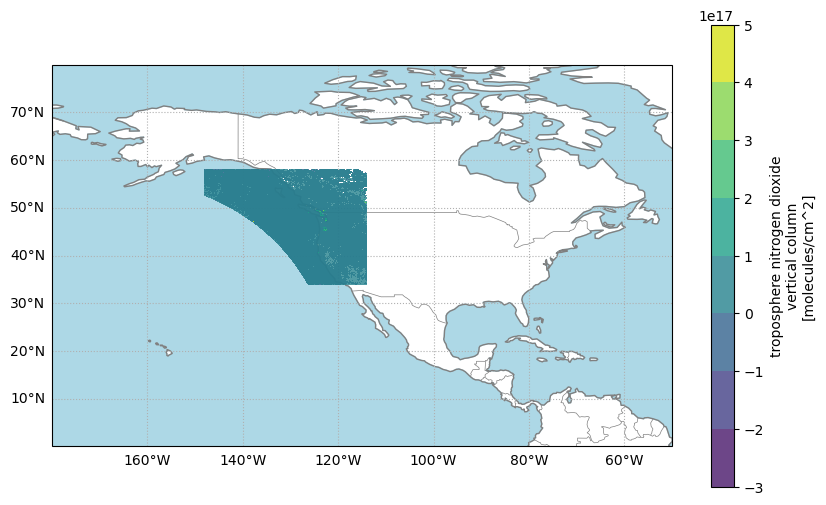

In [17]:
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={"projection": projection})

make_nice_map(ax)

contour_handle = ax.contourf(
    x, y, values,
    transform=ccrs.PlateCarree(),
    alpha=0.8,
    zorder=2,
)

cb = plt.colorbar(contour_handle)
cb.set_label(label_from_attrs(values))

plt.show()

### Selecting with logical conditions

In [18]:
lon_condition = (ds["longitude"] <= -120) & (ds["longitude"] >= -150)
lat_condition = (ds["latitude"] <= 60) & (ds["latitude"] >= 35)

x = ds["longitude"].where(lon_condition, drop=True)
y = ds["latitude"].where(lat_condition, drop=True)

values = (ds
    .vertical_column_troposphere
    .where(lon_condition & lat_condition, drop=True)
    .sel(time=datetime.strptime("2026-01-01T22:22:41", "%Y-%m-%dT%H:%M:%S"), method="nearest")
)
values

<xarray.DataArray 'vertical_column_troposphere' (latitude: 1250, longitude: 1500)> Size: 15MB
dask.array<getitem, shape=(1250, 1500), dtype=float64, chunksize=(737, 1500), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float32 5kB 35.01 35.03 35.05 ... 59.95 59.97 59.99
  * longitude  (longitude) float32 6kB -150.0 -150.0 -149.9 ... -120.0 -120.0
    time       datetime64[ns] 8B 2026-01-01T22:22:41.029656576
Attributes:
    long_name:  troposphere nitrogen dioxide vertical column
    units:      molecules/cm^2

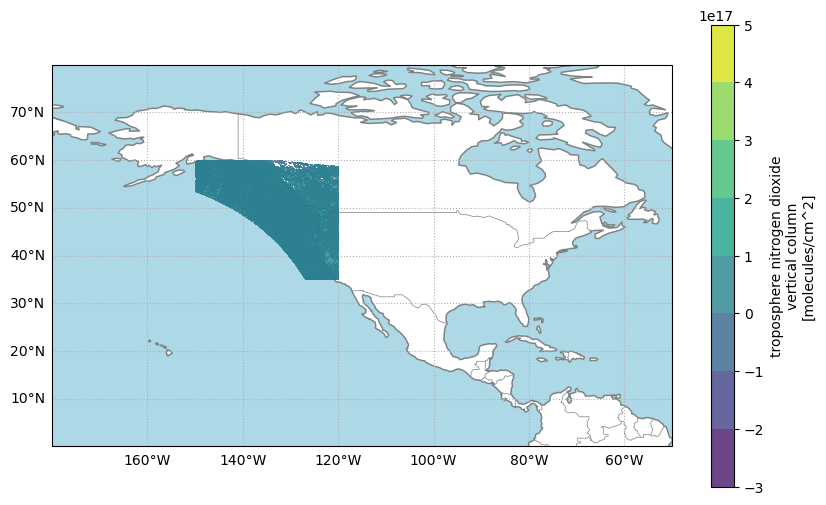

In [19]:
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={"projection": projection})

make_nice_map(ax)

contour_handle = ax.contourf(
    x, y, values,
    transform=ccrs.PlateCarree(),
    alpha=0.8,
    zorder=2,
)

cb = plt.colorbar(contour_handle)
cb.set_label(label_from_attrs(values))

plt.show()